# Naive Bayes

## Feature engineering

In [15]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/clean/target_data.csv')

In [16]:
df["ai_hours"] = df["ai_hours"].map({
    "Menos de 1 hora": 0,
    "1–2 horas": 1,
    "2–4 horas": 2,
    "Más de 4 horas": 3
})

df["social_interaction_frequency"] = df["social_interaction_frequency"].map({
    "Rara vez": 0,
    "Ocasionalmente": 1,
    "Frecuentemente": 2,
    "Muy frecuentemente": 3
})

df["ai_usage_frequency"] = df["ai_usage_frequency"].map({
    "Rara vez": 0,
    "Una vez al día": 1,
    "Varias veces al día": 2,
    "Algunas veces a la semana": 3
})

In [17]:
df["uses_ai_for_emotional_support"] = df["uses_ai_for_emotional_support"].astype(int)
df["follows_ai_advice"] = df["follows_ai_advice"].astype(int)

In [18]:
ayuda = LabelEncoder()
df["seeks_help_from_others"] = ayuda.fit_transform(df["seeks_help_from_others"])

uso = LabelEncoder()
df["ai_usage_type"] = uso.fit_transform(df["ai_usage_type"])

In [19]:
df.sample(10)

,age,career,ai_hours,ai_usage_frequency,ai_usage_type,ai_emotional_support_perception,ai_vs_human_interaction,ai_discomfort,ai_decision_support,ai_understanding,ai_vs_human_trust,social_interaction_frequency,seeks_help_from_others,uses_ai_for_emotional_support,follows_ai_advice,dependency_score,dependency_level,high_usage
30,18-21,Ingeniería / STEM,1,2,2,3,1,2,2,4,4,3,2,1,1,2.666667,medium,0
45,+25,Ciencias Sociales / Humanidades,0,2,0,5,5,1,3,3,5,3,0,1,1,3.666667,medium,0
106,18-21,Ingeniería / STEM,2,2,2,3,1,3,2,2,1,0,0,1,1,2.000000,low,1
3,22-24,Ingeniería / STEM,0,3,1,1,1,1,3,1,2,3,2,0,0,1.500000,low,0
89,22-24,Ingeniería / STEM,1,2,2,1,1,1,1,1,3,2,2,0,0,1.333333,low,0
23,18-21,Ciencias Sociales / Humanidades,1,2,2,2,2,3,3,3,3,2,2,1,0,2.666667,medium,0
9,18-21,Ingeniería / STEM,0,2,2,1,1,1,1,1,1,2,2,0,0,1.000000,low,0
82,18-21,Ingeniería / STEM,0,3,2,1,1,1,2,1,1,3,2,0,0,1.166667,low,0
52,18-21,Ciencias Sociales / Humanidades,3,2,2,1,1,1,1,2,3,3,2,1,0,1.500000,low,1
91,18-21,Otro,0,3,1,2,1,1,2,2,1,2,2,1,0,1.500000,low,0


In [20]:
X = df[[
    "ai_hours",
    "social_interaction_frequency",
    "ai_usage_frequency",
    "uses_ai_for_emotional_support",
    "follows_ai_advice",
    "seeks_help_from_others",
    "ai_usage_type"
]]

y = df["dependency_level"]  

In [21]:
X

,ai_hours,social_interaction_frequency,ai_usage_frequency,uses_ai_for_emotional_support,follows_ai_advice,seeks_help_from_others,ai_usage_type
0,2,0,2,1,1,2,2
1,1,3,2,0,1,0,2
2,0,3,2,1,0,0,2
3,0,3,3,0,0,2,1
4,1,3,1,1,0,2,2
...,...,...,...,...,...,...,...
135,0,3,0,1,1,2,2
136,0,3,0,0,0,2,2
137,0,1,1,0,0,2,2
138,0,2,1,0,0,2,2


In [22]:
y = df["dependency_level"].map({
    "low": 0,
    "medium": 1,
    "high": 2
})
y

0      1
1      0
2      1
3      0
4      0
      ..
135    2
136    0
137    0
138    0
139    0
Name: dependency_level, Length: 140, dtype: int64

In [23]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = CategoricalNB()
model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None


## Naive Bayes Model Evaluation

A Categorical Naive Bayes classifier was trained to predict AI dependency levels (low, medium, high) based on behavioral and demographic features.

The model performance was evaluated using accuracy, precision, recall, F1-score, and the confusion matrix.

In [24]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91        22
           1       0.67      0.40      0.50         5
           2       1.00      1.00      1.00         1

    accuracy                           0.86        28
   macro avg       0.85      0.78      0.80        28
weighted avg       0.84      0.86      0.84        28



### Accuracy

Accuracy represents the proportion of correctly classified observations over the total dataset.

While accuracy provides a global measure of performance, it does not capture class-wise behavior, especially in imbalanced datasets.

### Precision, Recall, and F1-score

- Precision measures how reliable the model's predictions are for each class.
- Recall measures how well the model identifies all actual instances of each class.
- F1-score balances precision and recall.

These metrics provide a more detailed understanding of model performance across dependency levels.

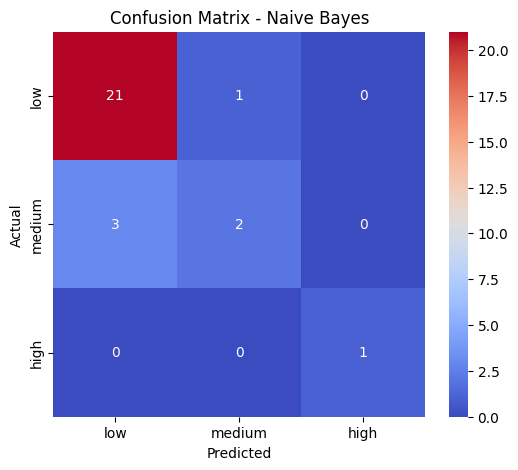

In [ ]:
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm",
            xticklabels=["low","medium","high"],
            yticklabels=["low","medium","high"])

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../paper/confusion_matrix.png", bbox_inches="tight")
plt.show()

### Confusion Matrix Analysis

The confusion matrix reveals that the model performs better in identifying low dependency cases, while medium cases are often misclassified as low. The high dependency class is underrepresented, which limits the model's ability to learn robust patterns for this category.

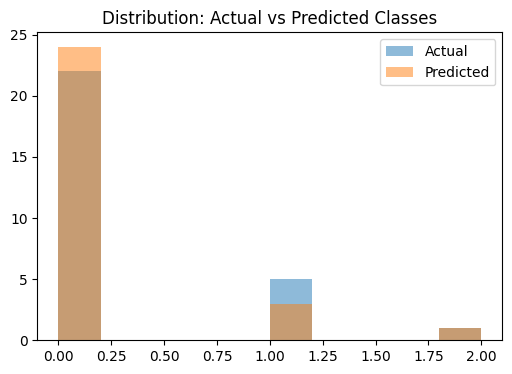

In [31]:

plt.figure(figsize=(6,4))
plt.hist(y_test, alpha=0.5, label="Actual")
plt.hist(y_pred, alpha=0.5, label="Predicted")
plt.legend()
plt.title("Distribution: Actual vs Predicted Classes")
plt.show()

The observed bias toward the low dependency class is not necessarily a model failure, but rather a reflection of the underlying class distribution and the ambiguity present in the medium dependency category.

In [26]:
df.to_csv('../data/clean/categorical_data.csv', index=0)